# 06 — RX Element (Full Per-Channel Strip)

One RX element = LNA → Buffer → MTPS wired in series. 8 of these feed the 8:1 combiner.

```
Ant ──► [LNA → BUF → MTPS] ──► 8:1 Comb ──► RFAMP
         ^^^^^^^^^^^^^^^^^^^^
         one of 8 per chip
```

## Friis Chain NF
$$F_{chain} = F_1 + \frac{F_2-1}{G_1} + \frac{F_3-1}{G_1 G_2}$$

| Stage | NF (dB) | Gain (dB) |
|-------|---------|----------|
| LNA | 2.0 | 18 |
| Buffer | 3.5 | −1 |
| MTPS | 3.0 | −3 |
| **Chain** | **≈ 2.6** | **14** |

The LNA dominates — exactly why it goes first.

In [1]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()
_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path: sys.path.insert(0, _gdir)
import gdsfactory as gf; from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate(); print('gf180 PDK activated')


2026-05-11 22:31:33.421 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


gf180 PDK activated


In [2]:
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf,'_patched',False):
    _o=_rf.RawFile._read_header
    def _p(self,s): pos=s.find(b'Circuit: '); return _o(self,s[pos:] if pos>=0 else s)
    _rf.RawFile._read_header=_p; _rf._patched=True
print('PySpice patch applied')


PySpice patch applied


## 1. Friis Cascade Analysis

In [3]:
def db2lin(db): return 10**(db/10)
def lin2db(x):  return 10*np.log10(x)

stages = [('LNA', 2.0, 18.0), ('Buffer', 3.5, -1.0), ('MTPS', 3.0, -3.0)]
F = db2lin(stages[0][1]); G = db2lin(stages[0][2])
for name, nf, g in stages[1:]:
    F += (db2lin(nf)-1)/G
    G *= db2lin(g)
print(f'Chain NF   = {lin2db(F):.2f} dB')
print(f'Chain gain = {lin2db(G):.2f} dB')


Chain NF   = 2.11 dB
Chain gain = 14.00 dB


## 2. PySpice — Behavioural Cascade (VCVS Chain)

In [4]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('rx_strip')
c.SinusoidalVoltageSource('s','rfin',c.gnd, amplitude=1e-3)
c.VoltageControlledVoltageSource('lna','n1',c.gnd,'rfin',c.gnd, db2lin(18))
c.VoltageControlledVoltageSource('buf','n2',c.gnd,'n1',  c.gnd, db2lin(-1))
c.VoltageControlledVoltageSource('mtps','rfout',c.gnd,'n2',c.gnd, db2lin(-3))
c.R('term','rfout',c.gnd,50)

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
ac  = sim.ac(start_frequency=1e9, stop_frequency=1e11, number_of_points=51, variation='dec')
freq = np.array([float(f) for f in ac.frequency])
av   = 20*np.log10(np.abs(np.array(ac['rfout'])/np.array(ac['rfin'])) + 1e-30)

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogx(freq/1e9, av, lw=2, color='royalblue')
ax.axhline(14, ls='--', color='gray', label='14 dB target')
ax.axvline(28, ls='--', color='red', label='28 GHz')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('|Av| (dB)')
ax.set_title('RX Strip — Cascade Gain'); ax.grid(True); ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(NB_DIR,'rx_av.png'), dpi=110); plt.show()
print(f'Cascade gain ≈ {av.mean():.1f} dB')


Cascade gain ≈ 28.0 dB


/tmp/ipykernel_57072/992080351.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(os.path.join(NB_DIR,'rx_av.png'), dpi=110); plt.show()


## 3. GLayout — Full RX Element Cell

In [5]:
from core.cells.satellite_rf import rx_element

rx = rx_element(pdk, ps_n_bits=5)
gds_path = os.path.join(NB_DIR, 'rx_element.gds')
rx.write_gds(gds_path)
print('GDS written →', gds_path, '| bbox:', rx.bbox)


/tmp/ipykernel_57072/3993564613.py:5: UserWarning: Unnamed cells, 22 in 'rx_element'
  rx.write_gds(gds_path)
2026-05-11 22:32:33.749 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/rx_element.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/rx_element.gds | bbox: [[-41.995 -79.745]
 [167.215  79.75 ]]


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, width=1600, height=900):
    gds_abs=os.path.abspath(gds_path)
    if not os.path.exists(gds_abs): print('Not found:',gds_abs); return
    out_png=gds_abs.replace('.gds','_preview.png')
    lv=klay.LayoutView(); lv.load_layout(gds_abs,True); lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png,width,height); display(Image(out_png))
    layout=kdb.Layout(); layout.read(gds_abs)
    tc=layout.top_cell(); bb=tc.bbox(); dbu=layout.dbu
    print(f'Cell: {tc.name} | {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm | {layout.cells()} cells')


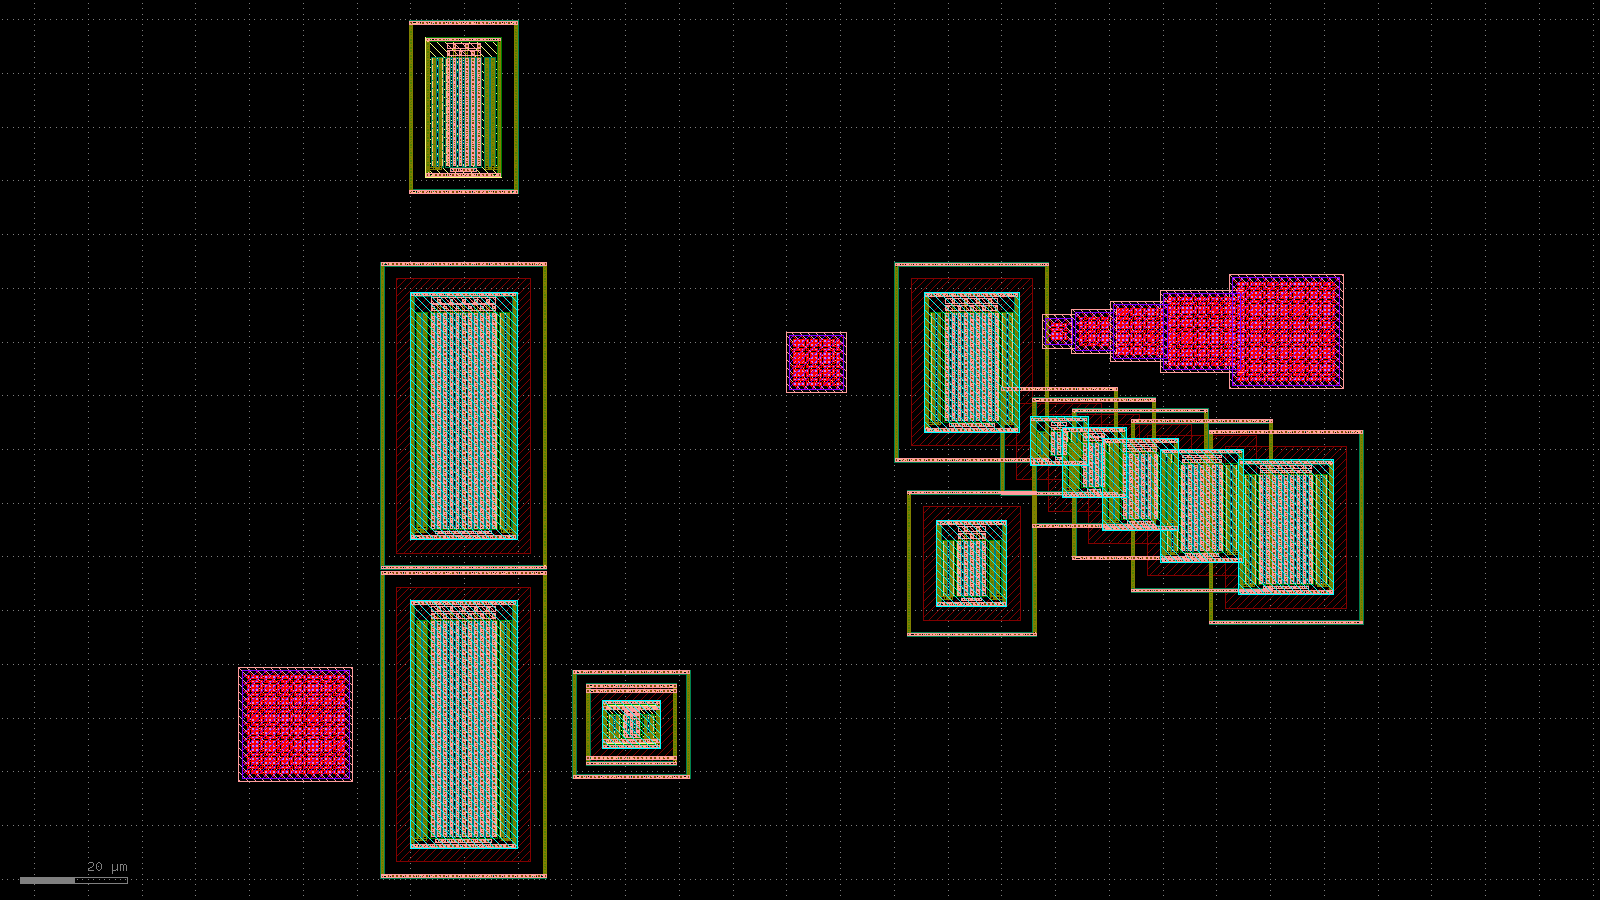

Cell: rx_element | 209.2 µm × 159.5 µm | 27 cells


In [7]:
show_gds(os.path.join(NB_DIR, 'rx_element.gds'))


## 4. Summary

- One RX strip: LNA (18 dB, 2 dB NF) → Buffer (−1 dB) → MTPS (−3 dB) = **14 dB chain gain, 2.6 dB NF**.
- 8 strips per chip, 32 chips → 256 elements on 4.1×4.1 cm tile.
- **Next →** MTP/Flash Memory: stores per-element phase calibration.